# The G/G/s Queue

A **G/G/s queue** is the multi-server version of the `G/G/1` queue: customers join one
line, and the customer at its head goes to whichever of the `s` servers comes free first.
The bank with several tellers, the call center with several agents. In **Kendall's
notation**, `G/G/s` is a **G**eneral distribution for the time between arrivals, a
**G**eneral distribution for the service times, and **s** servers.

| Class | Arrivals | Service | Servers |
|---|---|---|---|
| `GG1(interarrival_dist, service_dist)` | any distribution | any distribution | 1 |
| `GGs(interarrival_dist, service_dist, servers)` | any distribution | any distribution | s |

`X[n]` is again how long customer `n` waits in line, not counting their own service.
Nobody waits at all while any server is idle, so all the model has to keep track of is
**when each server next comes free**: an arriving customer takes the soonest one, and
waits `max(earliest free time - arrival time, 0)`. That is Lindley's recursion for
`GG1`, generalized to `s` servers.

In [9]:
from symbulate import *

## Defining the queue

Three tellers, a customer arriving every 2 minutes on average, and services averaging 5
minutes. `utilization` is the fraction of time a server is busy: the load is shared out
over the servers, so it is the average service time divided by `servers` times the
average gap between arrivals.

In [10]:
bank = GGs(
    interarrival_dist=Exponential(rate=1 / 2),
    service_dist=Gamma(shape=2, rate=2 / 5),
    servers=3,
)
print("utilization:", round(bank.utilization, 3))

path = bank.sim(1)
[round(path[n], 1) for n in range(10)]  # how long the first ten customers waited

utilization: 0.833


[Index Result
 0     0.0,
 Index Result
 0     0.0,
 Index Result
 0     0.0,
 Index Result
 0     0.0,
 Index Result
 0     0.0,
 Index Result
 0     0.0,
 Index Result
 0     0.0,
 Index Result
 0     0.0,
 Index Result
 0     0.0,
 Index Result
 0     0.6]

Simulate and plot sample paths as for any other random process.

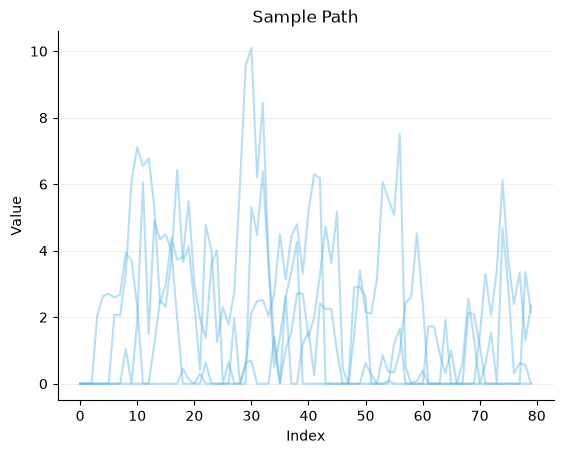

In [11]:
bank.sim(4).plot(tmin=0, tmax=80)

## What another server buys you

The same arrivals and the same service times, served by one, two, or three servers. One
server cannot keep up here (`utilization` above 1, so the line grows without bound);
two settle down; three barely wait at all.

1 server(s): utilization 1.250
2 server(s): utilization 0.625


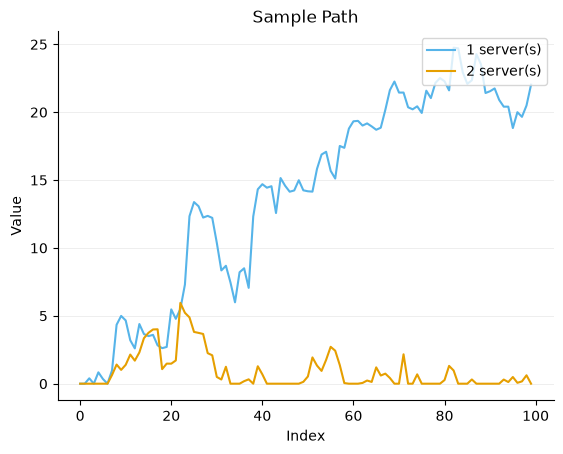

In [12]:
for servers in [1, 2]:
    queue = GGs(Exponential(rate=1), Exponential(rate=0.8), servers=servers)
    print(f"{servers} server(s): utilization {queue.utilization:.3f}")
    # One path each, so the three are easy to tell apart.
    queue.sim(1).plot(tmin=0, tmax=100, label=f"{servers} server(s)")

## One customer's wait

Index the queue at a customer number to get an ordinary random variable. With three
servers most customers walk straight up to one, which is the spike at 0.

3.8548335412684716

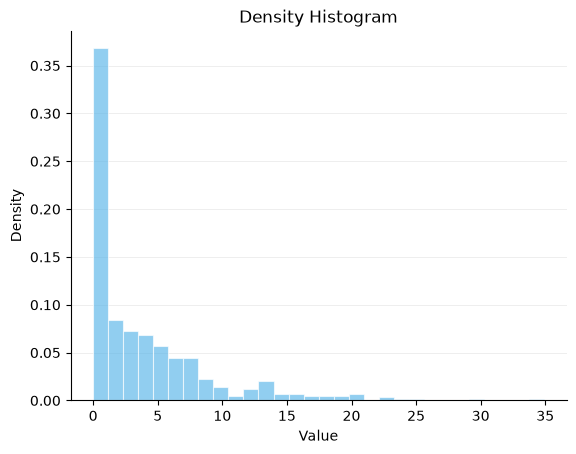

In [13]:
waits = bank[50].sim(500)
waits.plot()
waits.mean()

## The special case: M/M/s

Make both distributions exponential and you have an `M/M/s` queue -- Poisson arrivals,
exponential service. The `MMs` class in `markov_chains.py` models the same queue, but
reports the number of customers in the system over continuous time rather than each
customer's wait.

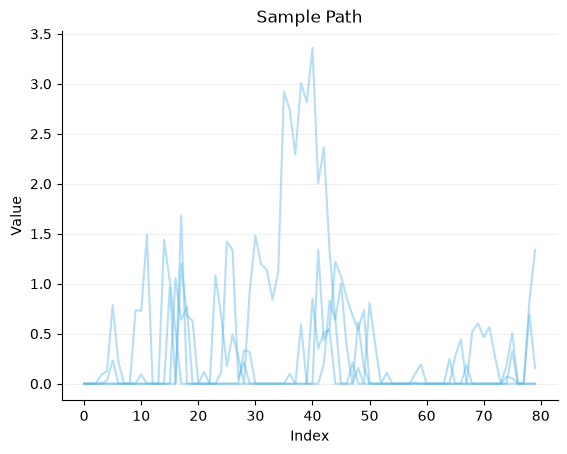

In [14]:
mms = GGs(Exponential(rate=1), Exponential(rate=1), servers=2)
mms.sim(4).plot(tmin=0, tmax=80)